In [1]:
import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg', 'pdf')
import seaborn as sns

import importlib.util
import subprocess
import sys

if importlib.util.find_spec("equinox") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "equinox"])

In [2]:
# BOOK_FIGURE_STYLE_CELL
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

try:
    import seaborn as sns
except ImportError:
    sns = None

try:
    import matplotlib_inline

    matplotlib_inline.backend_inline.set_matplotlib_formats("svg", "pdf")
except Exception:
    matplotlib_inline = None

FIGURE_SIZES = {
    "full_landscape": (4.50, 2.65),
    "full_standard": (7.35, 4.90),
    "full_tall": (7.35, 5.50),
    "half_standard": (3.55, 2.55),
    "half_tall": (3.55, 3.05),
    "inset": (2.30, 1.75),
}

BOOK_COLORS = {
    "blue": "#4C78A8",
    "orange": "#F58518",
    "green": "#54A24B",
    "red": "#E45756",
    "gray": "#7F7F7F",
}

BOOK_TARGET = "web"


def setup_book_style(target="web"):
    global BOOK_TARGET
    BOOK_TARGET = target
    mpl.rcParams.update(
        {
            "figure.figsize": FIGURE_SIZES["half_standard"],
            "figure.dpi": 120,
            "savefig.dpi": 300,
            "savefig.bbox": "tight",
            "savefig.pad_inches": 0.02,
            "pdf.fonttype": 42,
            "ps.fonttype": 42,
            "font.family": "sans-serif",
            "font.sans-serif": ["DejaVu Sans", "Arial", "Liberation Sans"],
            "axes.labelsize": 9,
            "axes.titlesize": 9,
            "axes.linewidth": 0.8,
            "axes.grid": False,
            "axes.spines.top": False,
            "axes.spines.right": False,
            "xtick.labelsize": 8,
            "ytick.labelsize": 8,
            "xtick.major.width": 0.8,
            "ytick.major.width": 0.8,
            "legend.fontsize": 8,
            "legend.frameon": False,
            "lines.linewidth": 1.5,
            "lines.markersize": 4,
            "patch.linewidth": 0.8,
            "image.cmap": "Greys",
        }
    )
    if target == "latex":
        try:
            mpl.rcParams["text.usetex"] = False
        except Exception:
            mpl.rcParams["text.usetex"] = False


def new_figure(
    size="half_standard",
    nrows=1,
    ncols=1,
    sharex=False,
    sharey=False,
    constrained=True,
    squeeze=True,
    **kwargs,
):
    fig, ax = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        sharex=sharex,
        sharey=sharey,
        constrained_layout=constrained,
        figsize=FIGURE_SIZES[size],
        squeeze=squeeze,
        **kwargs,
    )
    return fig, ax


def label_panels(axes=None, labels=None, x=0.02, y=0.98, **kwargs):
    if axes is None:
        axes = plt.gcf().axes
    axes = np.atleast_1d(axes).ravel()
    if labels is None:
        labels = [f"({chr(97 + i)})" for i in range(len(axes))]
    default = dict(
        fontsize=9,
        fontweight="bold",
        va="top",
        ha="left",
        transform=None,
        bbox=dict(facecolor="white", edgecolor="none", pad=0.8, alpha=0.9),
    )
    default.update(kwargs)
    for ax, label in zip(axes, labels):
        call_kwargs = dict(default)
        if call_kwargs["transform"] is None:
            call_kwargs["transform"] = ax.transAxes
        ax.text(x, y, label, **call_kwargs)


def finalize_axes(axes=None, keep_box=False, grid=False):
    if axes is None:
        axes = plt.gcf().axes
    axes = np.atleast_1d(axes).ravel()
    for ax in axes:
        if grid:
            ax.grid(axis="y", color="0.88", linewidth=0.6)
        else:
            ax.grid(False)
        for spine in ax.spines.values():
            spine.set_linewidth(0.8)
        if keep_box:
            ax.spines["top"].set_visible(True)
            ax.spines["right"].set_visible(True)
        else:
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)
    return axes


def grayscale_contourf(ax, x, y, values, levels, extend="neither"):
    filled = ax.contourf(
        x, y, values, levels=levels, cmap="Greys", extend=extend
    )
    value_min = float(np.nanmin(values))
    value_max = float(np.nanmax(values))
    line_levels = np.asarray(levels)
    line_levels = line_levels[
        (line_levels > value_min) & (line_levels < value_max)
    ]
    if line_levels.size:
        ax.contour(
            x, y, values, levels=line_levels, colors="black",
            linewidths=0.35, alpha=0.75
        )
    return filled


def save_book_figure(fig, basename, target="web", pdf=True, png=False):
    base = Path(basename)
    base.parent.mkdir(parents=True, exist_ok=True)
    if pdf:
        fig.savefig(base.with_suffix(".pdf"), bbox_inches="tight", pad_inches=0.02)
    if png:
        fig.savefig(base.with_suffix(".png"), bbox_inches="tight", pad_inches=0.02)


setup_book_style(target="web")


In [3]:
import jax
import equinox as eqx

class FourierEncoding(eqx.Module):
    B: jax.Array

    @property
    def num_fourier_features(self) -> int:
        return self.B.shape[0]

    @property
    def in_size(self) -> int:
        return self.B.shape[1]
    
    @property
    def out_size(self) -> int:
        return self.B.shape[0] * 2

    def __init__(self, 
                 in_size: int, 
                 num_fourier_features: int, 
                 key: jax.random.PRNGKey, 
                 sigma: float = 1.0):
        self.B = jax.random.normal(
            key, shape=(num_fourier_features, in_size),
            dtype=jax.numpy.float32) * sigma
    
    def __call__(self, x: jax.Array, **kwargs) -> jax.Array:
        return jax.numpy.concatenate(
            [jax.numpy.cos(jax.numpy.dot(self.B, x)),
             jax.numpy.sin(jax.numpy.dot(self.B, x))],
            axis=0)

# Solving Parametric Problems Using Physics-Informed Neural Networks


For a single forward solve, an established numerical solver is usually the practical starting point.
A *parametric problem* asks for the solution of an ODE or PDE at many parameter values. A parametric PINN shares the training effort across these repeated solves: it learns the map from parameters to solutions with one trained model. Whether that investment pays off depends on the accuracy needed and the number of subsequent evaluations.

The standard PINN approach extends to parametric problems by treating the parameters as additional inputs.
Suppose that the parameters are $\boldsymbol{\xi}$, an $\mathbb{R}^d$-valued random vector with density $p(\boldsymbol{\xi})$.
For each fixed $\boldsymbol{\xi}$, the integrated squared residual depends on the trainable network parameters $\theta$:

$$
\mathcal{L}(\theta;\boldsymbol{\xi}) = \int_{\Omega} \left\|R_{\boldsymbol{\xi}}[u_\theta](\mathbf{x})\right\|^2 \,d\mathbf{x}.
$$

The idea is three-fold. First, enforce the boundary and initial conditions through the parameterization.
Second, parameterize the unknown part using a neural network $N(\mathbf{x}, \boldsymbol{\xi};\theta)$ with parameters $\theta$.
A good choice for the parameterization is this structure:

$$
N(\mathbf{x}, \boldsymbol{\xi};\theta) = \sum_{i=1}^m b_i(\boldsymbol{\xi};\theta)\phi_i(\mathbf{x};\theta).
$$

This is a good choice because it resembles an expansion in a basis of functions $\phi_i(\mathbf{x};\theta)$ with coefficients $b_i(\boldsymbol{\xi};\theta)$.
The difference here is that the basis functions are learned—they are not fixed.
Third, we find the parameters $\theta$ by minimizing the residual loss averaged over the parameter distribution:

$$
\overline{\mathcal{L}}(\theta) = \int_{\mathbb{R}^d} \mathcal{L}(\theta;\boldsymbol{\xi}) p(\boldsymbol{\xi}) \,d\boldsymbol{\xi}.
$$

We can do this using Adam, or any other optimization algorithm.
All we need is to express the loss as an expectation and construct an unbiased estimator of the gradient of the loss with respect to the parameters $\theta$.



## Example: Parametric Poisson Equation

Let's consider the following parametric Poisson equation:

$$
\begin{aligned}
    -\Delta u(\mathbf{x};\xi) &= f(\mathbf{x};\xi), \quad \mathbf{x} \in \Omega, \\
    u(\mathbf{x};\xi) &= 0, \quad \mathbf{x}\in \partial\Omega,
\end{aligned}
$$

where $\Omega = [0,1]^2$.
The source term is:

$$
    f(\mathbf{x};\xi) = 2\pi^2\xi\sin(\pi x) \sin(\pi y).
$$

The exact solution to this problem is:

$$
u(\mathbf{x};\xi) = \xi\sin(\pi x) \sin(\pi y).
$$

Direct substitution shows that $\Delta u + f = 0$.

In [4]:
import sympy as sp
from sympy import symbols

x, y, xi = symbols('x y xi')
f = 2 * sp.pi ** 2 * xi * sp.sin(sp.pi * x) * sp.sin(sp.pi * y)
u = xi * sp.sin(sp.pi * x) * sp.sin(sp.pi * y)
res = sp.simplify(sp.diff(u, x, x) + sp.diff(u, y, y) + f)
res

0

I have purposely chosen a simple problem, so that we don't have to deal with non-dimensionalization and scaling.
A parameterization that satisfies the boundary conditions is:

$$
u(x,y;\xi;\theta) = x (1 - x) y (1 - y) N(x,y;\xi;\theta),
$$

where $N(x,y;\xi;\theta)$ is a neural network with parameters $\theta$.
For the neural network, we will use the structure suggested above.

First, some useful classes to avoid code repetition.

In [5]:
import equinox as eqx

class ParametricModel(eqx.Module):
    """This model captures a simple structure made out of branches and trunks."""
    branch: list  # These are the b's
    trunk: list   # These are the phi's

    def __init__(self, branch, trunk):
        self.branch = branch
        self.trunk = trunk

    def __call__(self, x, xi, **kwargs):
        res = 0.0
        for b, t in zip(self.branch, self.trunk):
            res += b(xi) * t(x)
        return res


class EnforceDirichletZeroBoundarySquare(eqx.Module):
    """This is an model that enforces zero Dirichlet boundary conditions on the square."""
    neural_net: eqx.Module

    def __init__(self, neural_net):
        self.neural_net = neural_net
    
    def __call__(self, x, y, xi, **kwargs):
        return self.neural_net(jnp.array([x, y]), xi) * (1 - x) * x * (1 - y) * y

Let's now make the actual model we will use:

In [6]:
import jax
import jax.numpy as jnp
import jax.random as jrandom

key = jrandom.PRNGKey(0)
key1, key2, key = jrandom.split(key, 3)

# Make the parameterization
m = 10 # number of branches and trunks
# Branches are all MLP's
branch_width = 32
branch_depth = 3
branch = [eqx.nn.MLP('scalar', 'scalar', branch_width, branch_depth, jax.nn.tanh, key=k) for k in jrandom.split(key1, m)]
# Trunks have a FourierEncoding followed by an MLP
trunk_num_fourier_features = 32
trunk_width = 32
trunk_depth = 3
trunk = [eqx.nn.Sequential([
    FourierEncoding(2, trunk_num_fourier_features, key=k),
    eqx.nn.MLP(trunk_num_fourier_features * 2, 'scalar', trunk_width, trunk_depth, jax.nn.tanh, key=k)
]) for k in jrandom.split(key2, m)]
# Combine the branches and trunks into a ParametricModel
model = EnforceDirichletZeroBoundarySquare(ParametricModel(branch, trunk))

Here is how our model looks like as a PyTree:

In [7]:
model

EnforceDirichletZeroBoundarySquare(
  neural_net=ParametricModel(
    branch=[
      MLP(
        layers=(
          Linear(
            weight=f32[32,1],
            bias=f32[32],
            in_features='scalar',
            out_features=32,
            use_bias=True
          ),
          Linear(
            weight=f32[32,32],
            bias=f32[32],
            in_features=32,
            out_features=32,
            use_bias=True
          ),
          Linear(
            weight=f32[32,32],
            bias=f32[32],
            in_features=32,
            out_features=32,
            use_bias=True
          ),
          Linear(
            weight=f32[1,32],
            bias=f32[1],
            in_features=32,
            out_features='scalar',
            use_bias=True
          )
        ),
        activation=<PjitFunction of <function tanh at 0x117a57240>>,
        final_activation=<function <lambda>>,
        use_bias=True,
        use_final_bias=True,
        in_size='scalar

Let's ensure our model works:

In [8]:
model(0.5, 0.5, 0.5)

Array(0.00453925, dtype=float32)

Let's create our loss function:

In [9]:
from jax import vmap, grad

def loss_density(model, x, y, xi):
    u_xx = grad(grad(model, 0), 0)(x, y, xi)
    u_yy = grad(grad(model, 1), 1)(x, y, xi)
    f = 2 * jnp.pi ** 2 * xi * jnp.sin(jnp.pi * x) * jnp.sin(jnp.pi * y)
    return (u_xx + u_yy + f) ** 2

# This evaluate the loss at multiple xs and ys, but at a single xi
loss_density_single_xi = vmap(loss_density, in_axes=(None, 0, 0, None))

# Τhis evaluates the loss at multiple xs, ys, and xis.
# But the xs and ys are the same for all xis
loss_density_many_xis = vmap(loss_density_single_xi, in_axes=(None, None, None, 0))

# And the final loss
loss = lambda model, xs, ys, xis: jnp.mean(loss_density_many_xis(model, xs, ys, xis))

Let's make sure it works:

In [10]:
xs = jnp.linspace(0, 1, 100)
ys = jnp.linspace(0, 1, 100)
xis = jnp.linspace(0, 1, 20)
res = loss_density_many_xis(model, xs, ys, xis)
res.shape

(20, 100)

And:

In [11]:
loss(model, xs, ys, xis)

Array(48.873215, dtype=float32)

We are not going to worry about the Fourier features. We will let the model learn them.
Here is the training code:

In [12]:
def train_parametric_pinn(
        loss,
        model,
        key,
        optimizer,
        Lx=1.0,
        Ly=1.0,
        num_collocation_residual=128,
        num_xis = 16,
        num_iter=10_000,
        freq=1,
    ):
    """Notice that it assumes the xi's are scalar and uniformly distributed in [0, 1]."""

    @eqx.filter_jit
    def step(opt_state, model, xs, ys, xis):
        value, grads = eqx.filter_value_and_grad(loss)(model, xs, ys, xis)
        updates, opt_state = optimizer.update(grads, opt_state)
        model = eqx.apply_updates(model, updates)
        return model, opt_state, value
    
    opt_state = optimizer.init(eqx.filter(model, eqx.is_inexact_array))
    
    losses = []
    for i in range(num_iter):
        key1, key2, key3, key = jrandom.split(key, 4)
        xs = jrandom.uniform(key1, (num_collocation_residual,), maxval=Lx)
        ys = jrandom.uniform(key2, (num_collocation_residual,), maxval=Ly)
        xis = jrandom.uniform(key3, (num_xis,))
        model, opt_state, value = step(opt_state, model, xs, ys, xis)
        if i % freq == 0:
            losses.append(value)
            print(f"Step {i}, residual loss {value:.3e}")
    return model, losses

Let's train. Be patient. It takes a while to compile the model. Once the iterations start, it is faster. It takes about 2.5 minutes to run on my machine.

In [13]:
import optax

optimizer = optax.adam(1e-3)

model, losses = train_parametric_pinn(
    loss, model, key, optimizer,
    num_collocation_residual=128, num_xis=2,
    num_iter=1_000, freq=1)

Step 0, residual loss 2.934e+01
Step 1, residual loss 3.251e+01
Step 2, residual loss 2.580e+00
Step 3, residual loss 1.213e+01
Step 4, residual loss 1.659e+01
Step 5, residual loss 2.704e+01
Step 6, residual loss 8.957e+00
Step 7, residual loss 3.519e+01
Step 8, residual loss 1.269e+00
Step 9, residual loss 3.543e+00
Step 10, residual loss 2.486e+01
Step 11, residual loss 1.857e+01
Step 12, residual loss 1.566e+00
Step 13, residual loss 1.784e+01
Step 14, residual loss 1.313e+01
Step 15, residual loss 1.627e+01
Step 16, residual loss 3.932e+00
Step 17, residual loss 7.830e+00
Step 18, residual loss 1.468e+01
Step 19, residual loss 1.112e+01
Step 20, residual loss 1.499e+01
Step 21, residual loss 1.085e+01
Step 22, residual loss 1.079e+01
Step 23, residual loss 8.235e+00
Step 24, residual loss 9.370e+00
Step 25, residual loss 4.011e+00
Step 26, residual loss 6.044e+00
Step 27, residual loss 2.327e+01
Step 28, residual loss 3.591e+00


Step 29, residual loss 2.529e+01
Step 30, residual loss 1.264e+01
Step 31, residual loss 9.745e+00
Step 32, residual loss 3.285e+00
Step 33, residual loss 1.315e+01
Step 34, residual loss 3.477e+00
Step 35, residual loss 8.162e+00
Step 36, residual loss 3.958e+00
Step 37, residual loss 2.255e+00
Step 38, residual loss 6.086e+00
Step 39, residual loss 9.373e+00
Step 40, residual loss 6.502e+00
Step 41, residual loss 6.540e+00
Step 42, residual loss 4.818e+00
Step 43, residual loss 6.874e+00
Step 44, residual loss 2.326e+00
Step 45, residual loss 3.054e+00
Step 46, residual loss 1.641e+00
Step 47, residual loss 2.145e+00
Step 48, residual loss 1.461e+00
Step 49, residual loss 4.993e+00
Step 50, residual loss 5.748e+00
Step 51, residual loss 3.422e+00
Step 52, residual loss 8.000e-01
Step 53, residual loss 1.174e+00
Step 54, residual loss 3.382e-01
Step 55, residual loss 5.504e-01
Step 56, residual loss 7.046e-01
Step 57, residual loss 3.842e-01
Step 58, residual loss 1.910e+00
Step 59, r

Step 65, residual loss 8.187e-01
Step 66, residual loss 4.875e-01
Step 67, residual loss 5.218e-01
Step 68, residual loss 1.999e-01
Step 69, residual loss 5.049e-01
Step 70, residual loss 1.786e-01
Step 71, residual loss 5.132e-01
Step 72, residual loss 4.690e-02
Step 73, residual loss 1.463e-01
Step 74, residual loss 4.817e-02
Step 75, residual loss 5.481e-01
Step 76, residual loss 1.531e-01
Step 77, residual loss 1.071e-01
Step 78, residual loss 1.522e-01
Step 79, residual loss 2.448e-01
Step 80, residual loss 3.280e-01
Step 81, residual loss 1.469e-01
Step 82, residual loss 2.182e-01
Step 83, residual loss 2.932e-01
Step 84, residual loss 4.526e-02
Step 85, residual loss 1.440e-01
Step 86, residual loss 5.864e-02
Step 87, residual loss 2.768e-01
Step 88, residual loss 3.171e-01
Step 89, residual loss 9.688e-02
Step 90, residual loss 3.487e-02
Step 91, residual loss 2.092e-01
Step 92, residual loss 3.495e-02
Step 93, residual loss 1.543e-01
Step 94, residual loss 1.083e-01
Step 95, r

Step 100, residual loss 2.980e-01
Step 101, residual loss 1.877e-02
Step 102, residual loss 1.665e-02
Step 103, residual loss 1.655e-01
Step 104, residual loss 3.257e-02
Step 105, residual loss 2.689e-02
Step 106, residual loss 2.386e-02
Step 107, residual loss 2.544e-02
Step 108, residual loss 2.289e-02
Step 109, residual loss 2.808e-02
Step 110, residual loss 3.080e-02
Step 111, residual loss 6.604e-02
Step 112, residual loss 1.093e-01
Step 113, residual loss 3.790e-02
Step 114, residual loss 6.480e-03
Step 115, residual loss 1.665e-02
Step 116, residual loss 1.373e-02
Step 117, residual loss 2.057e-01
Step 118, residual loss 3.292e-02
Step 119, residual loss 1.170e-02
Step 120, residual loss 8.952e-03
Step 121, residual loss 1.664e-01
Step 122, residual loss 7.689e-03
Step 123, residual loss 6.365e-02
Step 124, residual loss 2.739e-02
Step 125, residual loss 2.662e-02
Step 126, residual loss 9.115e-03
Step 127, residual loss 5.490e-02
Step 128, residual loss 6.693e-02
Step 129, resi

Step 135, residual loss 5.027e-02
Step 136, residual loss 1.350e-01
Step 137, residual loss 3.621e-02
Step 138, residual loss 4.103e-02
Step 139, residual loss 1.745e-01
Step 140, residual loss 6.562e-02
Step 141, residual loss 6.557e-02
Step 142, residual loss 6.470e-02
Step 143, residual loss 6.187e-03
Step 144, residual loss 2.980e-03
Step 145, residual loss 7.282e-02
Step 146, residual loss 1.210e-01
Step 147, residual loss 2.416e-01
Step 148, residual loss 4.900e-02
Step 149, residual loss 9.105e-02
Step 150, residual loss 1.391e-01
Step 151, residual loss 3.337e-02
Step 152, residual loss 4.934e-02
Step 153, residual loss 1.568e-01
Step 154, residual loss 2.254e-01
Step 155, residual loss 5.449e-02
Step 156, residual loss 4.938e-02
Step 157, residual loss 2.394e-01
Step 158, residual loss 1.375e-01
Step 159, residual loss 1.016e-02
Step 160, residual loss 3.447e-03
Step 161, residual loss 4.202e-03
Step 162, residual loss 1.301e-02
Step 163, residual loss 8.992e-03
Step 164, resi

...

Step 848, residual loss 2.452e-02
Step 849, residual loss 4.141e-02
Step 850, residual loss 1.405e-02
Step 851, residual loss 1.935e-02
Step 852, residual loss 4.558e-03
Step 853, residual loss 1.028e-02
Step 854, residual loss 2.839e-02
Step 855, residual loss 3.559e-02
Step 856, residual loss 2.184e-03
Step 857, residual loss 1.973e-03
Step 858, residual loss 6.280e-02
Step 859, residual loss 5.723e-03
Step 860, residual loss 1.106e-03
Step 861, residual loss 7.383e-03
Step 862, residual loss 7.106e-03
Step 863, residual loss 3.115e-03
Step 864, residual loss 1.412e-02
Step 865, residual loss 7.085e-03
Step 866, residual loss 1.990e-03
Step 867, residual loss 8.282e-03
Step 868, residual loss 9.692e-03
Step 869, residual loss 1.026e-03
Step 870, residual loss 1.522e-02
Step 871, residual loss 1.900e-02
Step 872, residual loss 1.085e-02
Step 873, residual loss 1.437e-03
Step 874, residual loss 1.066e-02
Step 875, residual loss 7.488e-03
Step 876, residual loss 8.720e-02
Step 877, resi

Step 883, residual loss 1.086e-03
Step 884, residual loss 2.429e-02
Step 885, residual loss 1.576e-02
Step 886, residual loss 7.317e-03
Step 887, residual loss 5.364e-03
Step 888, residual loss 2.129e-02
Step 889, residual loss 3.751e-03
Step 890, residual loss 7.249e-03
Step 891, residual loss 4.481e-03
Step 892, residual loss 2.104e-02
Step 893, residual loss 1.980e-03
Step 894, residual loss 2.817e-03
Step 895, residual loss 2.864e-03
Step 896, residual loss 3.409e-02
Step 897, residual loss 6.145e-04
Step 898, residual loss 5.931e-03
Step 899, residual loss 1.757e-02
Step 900, residual loss 9.128e-03
Step 901, residual loss 1.074e-03
Step 902, residual loss 6.492e-03
Step 903, residual loss 5.929e-03
Step 904, residual loss 3.693e-03
Step 905, residual loss 1.874e-02
Step 906, residual loss 1.538e-03
Step 907, residual loss 6.637e-03
Step 908, residual loss 7.022e-03
Step 909, residual loss 3.031e-03
Step 910, residual loss 7.563e-04
Step 911, residual loss 9.583e-04
Step 912, resi

Step 918, residual loss 2.161e-03
Step 919, residual loss 2.392e-03
Step 920, residual loss 1.379e-02
Step 921, residual loss 6.704e-03
Step 922, residual loss 1.638e-02
Step 923, residual loss 6.678e-03
Step 924, residual loss 7.254e-04
Step 925, residual loss 1.307e-03
Step 926, residual loss 8.416e-04
Step 927, residual loss 2.615e-02
Step 928, residual loss 5.143e-03
Step 929, residual loss 8.037e-03
Step 930, residual loss 1.166e-02
Step 931, residual loss 3.049e-02
Step 932, residual loss 9.853e-04
Step 933, residual loss 1.588e-03
Step 934, residual loss 4.229e-03
Step 935, residual loss 5.584e-03
Step 936, residual loss 2.160e-03
Step 937, residual loss 1.601e-02
Step 938, residual loss 2.990e-03
Step 939, residual loss 1.366e-02
Step 940, residual loss 4.375e-03
Step 941, residual loss 1.147e-02
Step 942, residual loss 3.803e-04
Step 943, residual loss 2.088e-02
Step 944, residual loss 1.921e-02
Step 945, residual loss 7.166e-03
Step 946, residual loss 1.279e-02
Step 947, resi

Step 953, residual loss 1.452e-03
Step 954, residual loss 2.552e-02
Step 955, residual loss 1.880e-03
Step 956, residual loss 3.906e-03
Step 957, residual loss 2.200e-03
Step 958, residual loss 1.683e-03
Step 959, residual loss 4.479e-03
Step 960, residual loss 2.250e-02
Step 961, residual loss 2.373e-03
Step 962, residual loss 4.336e-03
Step 963, residual loss 6.559e-03
Step 964, residual loss 4.696e-03
Step 965, residual loss 3.882e-02
Step 966, residual loss 1.339e-02
Step 967, residual loss 1.763e-03
Step 968, residual loss 4.061e-02
Step 969, residual loss 1.166e-02
Step 970, residual loss 2.396e-02
Step 971, residual loss 1.669e-03
Step 972, residual loss 2.009e-03
Step 973, residual loss 1.083e-02
Step 974, residual loss 1.071e-02
Step 975, residual loss 5.586e-02
Step 976, residual loss 5.062e-03
Step 977, residual loss 1.952e-02
Step 978, residual loss 5.170e-03
Step 979, residual loss 4.375e-02
Step 980, residual loss 3.481e-02


Step 981, residual loss 1.147e-02
Step 982, residual loss 1.219e-02
Step 983, residual loss 1.923e-02
Step 984, residual loss 1.634e-02
Step 985, residual loss 1.263e-02
Step 986, residual loss 2.723e-03
Step 987, residual loss 1.917e-03
Step 988, residual loss 2.373e-02
Step 989, residual loss 3.366e-02
Step 990, residual loss 9.081e-03
Step 991, residual loss 7.623e-04
Step 992, residual loss 6.797e-03
Step 993, residual loss 7.661e-03
Step 994, residual loss 1.393e-02
Step 995, residual loss 1.157e-02
Step 996, residual loss 4.650e-04
Step 997, residual loss 1.217e-03
Step 998, residual loss 1.686e-02
Step 999, residual loss 2.141e-02


Let's visualize the loss:

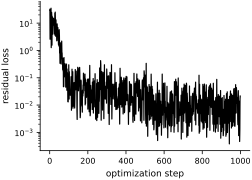

In [14]:
fig, ax = new_figure("half_standard")
steps = np.arange(len(losses))
ax.plot(steps, losses, color="black", linewidth=1.2)
ax.set_yscale("log")
ax.set(xlabel="optimization step", ylabel="residual loss")
finalize_axes(ax)
plt.show()

Let's compare the prediction and exact solution at five reproducible values of $\xi$:

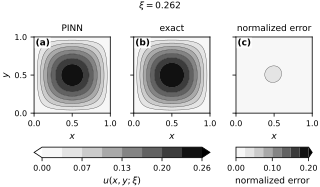

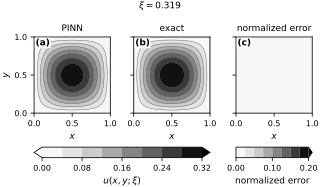

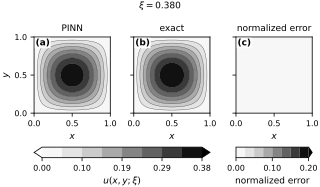

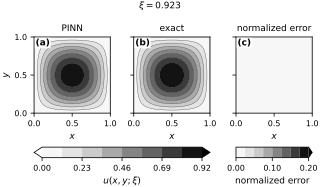

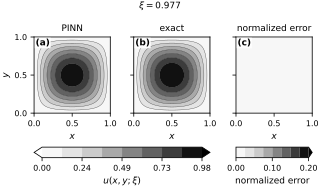

In [15]:
rng = np.random.default_rng(1234)

@eqx.filter_jit
def predict_on_grid(model, x, y, xi):
    return vmap(lambda x_i, y_i: model(x_i, y_i, xi))(x, y)

exact_on_grid = jax.jit(
    vmap(
        lambda x, y, xi: xi * jnp.sin(jnp.pi * x) * jnp.sin(jnp.pi * y),
        in_axes=(0, 0, None),
    )
)

xs = np.linspace(0, 1, 100)
ys = np.linspace(0, 1, 100)
X, Y = np.meshgrid(xs, ys)
X_flat = X.flatten()
Y_flat = Y.flatten()

error_levels = np.linspace(0.0, 0.2, 9)
parameter_values = np.sort(rng.random(5))

for xi in parameter_values:
    fig = plt.figure(
        figsize=FIGURE_SIZES["full_landscape"], layout="constrained"
    )
    grid = fig.add_gridspec(
        2, 3, height_ratios=(1.0, 0.09), hspace=0.08, wspace=0.10
    )
    axes = np.array([fig.add_subplot(grid[0, i]) for i in range(3)])
    solution_cax = fig.add_subplot(grid[1, :2])
    error_cax = fig.add_subplot(grid[1, 2])
    Z_p = np.asarray(
        predict_on_grid(model, X_flat, Y_flat, xi)
    ).reshape(X.shape)
    Z_t = np.asarray(exact_on_grid(X_flat, Y_flat, xi)).reshape(X.shape)
    solution_levels = np.linspace(0.0, float(xi), 9)

    c_solution = grayscale_contourf(
        axes[0], X, Y, Z_p, levels=solution_levels, extend="both"
    )
    grayscale_contourf(
        axes[1], X, Y, Z_t, levels=solution_levels
    )
    denominator = float(np.max(np.abs(Z_t)))
    relative_error = np.abs(Z_p - Z_t) / denominator
    c_error = grayscale_contourf(
        axes[2], X, Y, relative_error, levels=error_levels, extend="max"
    )

    axes[0].set_title("PINN")
    axes[1].set_title("exact")
    axes[2].set_title("normalized error")
    for axis in axes:
        axis.set(xlabel=r'$x$', xticks=[0.0, 0.5, 1.0], yticks=[0.0, 0.5, 1.0])
        axis.set_aspect("equal")
    axes[0].set_ylabel(r'$y$')
    axes[1].tick_params(labelleft=False)
    axes[2].tick_params(labelleft=False)

    fig.colorbar(
        c_solution, cax=solution_cax, orientation="horizontal",
        ticks=solution_levels[::2], format="%.2f", label=r'$u(x,y;\xi)$'
    )
    fig.colorbar(
        c_error, cax=error_cax, orientation="horizontal",
        ticks=error_levels[::4], format="%.2f", label="normalized error"
    )
    fig.suptitle(fr'$\xi = {xi:.3f}$', fontsize=9)
    label_panels(axes)
    finalize_axes(axes, keep_box=True)
    plt.show()

The model captures the main spatial structure at this parameter value. Further training may reduce the remaining discrepancy; a held-out comparison is needed to check whether it does.